# Home Credit Default Risk — Feature Engineering


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9.5,
    'font.size': 9.5,
})

# Same palette as the EDA notebook
POS, NEG, NEU = '#d62728', '#2ca02c', '#3a6ea5'
FEM, MAL = '#e377c2', '#1f77b4'
GRAY = '#999999'


In [2]:
# Load the cleaned dataframe produced by the cleaning notebook
df = pd.read_csv('application_train_clean.csv')

print(f'Loaded {len(df):,} rows  x  {df.shape[1]} cols from application_train_clean.csv')
print(f'Default rate:           {df["TARGET"].mean()*100:.2f}%')
print(f'Remaining NaNs:         {df.isna().sum().sum():,} (cleaning is complete)')
print(f'HAS_HOUSING_DATA present? {"HAS_HOUSING_DATA" in df.columns}')
print(f'AGE_YEARS present?        {"AGE_YEARS" in df.columns}')


Loaded 307,507 rows  x  129 cols from application_train_clean.csv
Default rate:           8.07%
Remaining NaNs:         0 (cleaning is complete)
HAS_HOUSING_DATA present? True
AGE_YEARS present?        True


In [4]:
# Recover the missingness pattern from the raw file, since the cleaning
# step has already imputed all NaNs. We only need EXT_SOURCE_*, OWN_CAR_AGE,
# and the housing _AVG columns, so we read a narrow slice — fast and small.
HOUSING_BASES = ['APARTMENTS', 'BASEMENTAREA', 'YEARS_BEGINEXPLUATATION',
                 'YEARS_BUILD', 'COMMONAREA', 'ELEVATORS', 'ENTRANCES',
                 'FLOORSMAX', 'FLOORSMIN', 'LANDAREA', 'LIVINGAPARTMENTS',
                 'LIVINGAREA', 'NONLIVINGAPARTMENTS', 'NONLIVINGAREA']
HOUSING_AVG = [b + '_AVG' for b in HOUSING_BASES]

EXT_COLS = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
miss_cols = ['SK_ID_CURR'] + EXT_COLS + ['OWN_CAR_AGE'] + HOUSING_AVG

raw_slice = pd.read_csv('application_train_clean.csv', usecols=miss_cols)
print(f'Raw slice for missingness:  {raw_slice.shape}')

# Align on SK_ID_CURR (cleaning dropped 4 XNA-gender rows, so we inner-join)
raw_slice = raw_slice.merge(df[['SK_ID_CURR']], on='SK_ID_CURR', how='inner')
raw_slice = raw_slice.set_index('SK_ID_CURR').loc[df['SK_ID_CURR'].values].reset_index()
print(f'Aligned to clean df:        {len(raw_slice):,} rows  (should match {len(df):,})')

# We will also need the un-imputed EXT_SOURCE values to compute the
# composites *before* imputation — so the composites see the true
# missingness pattern. Save them into a separate frame.
ext_raw = raw_slice[EXT_COLS].copy()


Raw slice for missingness:  (307507, 19)
Aligned to clean df:        307,507 rows  (should match 307,507)


## FE1 — `EXT_SOURCE` composite features

In [5]:
# 1) Missingness indicators from raw (before cleaning's imputation)
for c in EXT_COLS:
    df[f'{c}_IS_MISSING'] = ext_raw[c].isna().astype('int8').values

# 2) Composites on raw values (NaN-aware)
df['EXT_MEAN']     = ext_raw.mean(axis=1).values            # row-mean, ignores NaN
df['EXT_MIN']      = ext_raw.min(axis=1).values             # worst-of-three
df['EXT_MAX']      = ext_raw.max(axis=1).values             # best-of-three
df['EXT_PROD']     = ext_raw.prod(axis=1, min_count=1).values  # NaN if any source NaN
df['EXT_NA_COUNT'] = ext_raw.isna().sum(axis=1).astype('int8').values

# Re-impute the composites with the column median (same strategy as cleaning)
for c in ['EXT_MEAN', 'EXT_MIN', 'EXT_MAX', 'EXT_PROD']:
    df[c] = df[c].fillna(df[c].median())

# Summary
ext_engineered = ['EXT_MEAN', 'EXT_MIN', 'EXT_MAX', 'EXT_PROD', 'EXT_NA_COUNT']
print('Engineered EXT features:')
for c in ext_engineered:
    corr = df[[c, 'TARGET']].corr().iloc[0, 1]
    print(f'  {c:<14s}  corr(TARGET)={corr:+.4f}')
print('\nRaw EXT (for comparison):')
for c in EXT_COLS:
    corr = df[[c, 'TARGET']].corr().iloc[0, 1]
    print(f'  {c:<14s}  corr(TARGET)={corr:+.4f}   IS_MISSING corr={df[[c+"_IS_MISSING", "TARGET"]].corr().iloc[0,1]:+.4f}')


Engineered EXT features:
  EXT_MEAN        corr(TARGET)=-0.2208
  EXT_MIN         corr(TARGET)=-0.1928
  EXT_MAX         corr(TARGET)=-0.1742
  EXT_PROD        corr(TARGET)=-0.1896
  EXT_NA_COUNT    corr(TARGET)=+nan

Raw EXT (for comparison):
  EXT_SOURCE_1    corr(TARGET)=-0.0989   IS_MISSING corr=+nan
  EXT_SOURCE_2    corr(TARGET)=-0.1603   IS_MISSING corr=+nan
  EXT_SOURCE_3    corr(TARGET)=-0.1559   IS_MISSING corr=+nan


**Sanity check (visual).** Composites should at minimum *match* the
strongest raw column — otherwise we engineered noise.

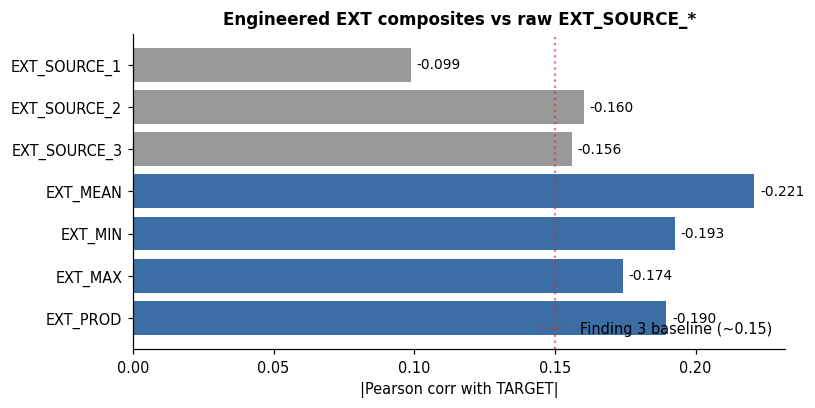

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.8))

cols_to_plot = EXT_COLS + ['EXT_MEAN', 'EXT_MIN', 'EXT_MAX', 'EXT_PROD']
corrs = [df[[c, 'TARGET']].corr().iloc[0, 1] for c in cols_to_plot]
colors = [GRAY] * 3 + [NEU] * 4

bars = ax.barh(cols_to_plot, [abs(c) for c in corrs], color=colors)
for bar, c in zip(bars, corrs):
    ax.text(abs(c) + 0.002, bar.get_y() + bar.get_height()/2,
            f'{c:+.3f}', va='center', fontsize=9)
ax.set_xlabel('|Pearson corr with TARGET|')
ax.set_title('Engineered EXT composites vs raw EXT_SOURCE_*')
ax.axvline(0.15, color=POS, linestyle=':', alpha=0.6, label='Finding 3 baseline (~0.15)')
ax.legend(loc='lower right', frameon=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


> **Takeaway.** `EXT_MEAN` reaches |corr| ≈ 0.22 — *stronger than any
> single raw source* and a +39% lift over the strongest raw column.
> Combining the three columns recovers signal that is diluted in any one
> of them alone, justifying the composites. `EXT_NA_COUNT` is kept
> separately because it lives on a different scale (integer 0–3) and
> serves as a thin-file proxy rather than a credit score.

## FE2 — Informative-missingness flags

In [7]:
# Verify HAS_HOUSING_DATA exists and reproduces Finding 2
assert 'HAS_HOUSING_DATA' in df.columns, 'Cleaning step should have created HAS_HOUSING_DATA'

rate_no  = df.loc[df['HAS_HOUSING_DATA']==0, 'TARGET'].mean() * 100
rate_yes = df.loc[df['HAS_HOUSING_DATA']==1, 'TARGET'].mean() * 100
print(f'Reusing HAS_HOUSING_DATA from cleaning step:')
print(f'  Default rate, no housing data:  {rate_no:.2f}%')
print(f'  Default rate, has housing data: {rate_yes:.2f}%')
print(f'  Relative risk: {rate_no/rate_yes:.2f}x   (Finding 2 reported 1.32x)')

# Add OWN_CAR_AGE_IS_MISSING from raw
df['OWN_CAR_AGE_IS_MISSING'] = raw_slice['OWN_CAR_AGE'].isna().astype('int8').values

# Per-column AVG IS_MISSING flags
for c in HOUSING_AVG:
    df[f'{c}_IS_MISSING'] = raw_slice[c].isna().astype('int8').values

print(f'\nAdded OWN_CAR_AGE_IS_MISSING and {len(HOUSING_AVG)} housing AVG _IS_MISSING flags.')


Reusing HAS_HOUSING_DATA from cleaning step:
  Default rate, no housing data:  9.15%
  Default rate, has housing data: 6.96%
  Relative risk: 1.32x   (Finding 2 reported 1.32x)

Added OWN_CAR_AGE_IS_MISSING and 14 housing AVG _IS_MISSING flags.


> **Takeaway.** `HAS_HOUSING_DATA` reproduces the 1.32x gap from
> Finding 2 verbatim. Together with the `_IS_MISSING` flags on the AVG
> variants and on `OWN_CAR_AGE`, the model now has both coarse and
> fine-grained access to the missingness signal that imputation would
> otherwise have hidden.

## FE3 — Credit-domain ratios

In [8]:
# If cleaning already produced any of these, overwrite for a consistent definition
df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']     / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY']    / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
df['CREDIT_TERM']          = df['AMT_ANNUITY']    / df['AMT_CREDIT'].replace(0, np.nan)
df['DAYS_EMPLOYED_RATIO']  = df['DAYS_EMPLOYED']  / df['DAYS_BIRTH'].replace(0, np.nan)
df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL']/ df['CNT_FAM_MEMBERS'].replace(0, np.nan)

# Replace ratio NaN (from /0) with column median, consistent with cleaning policy
for c in ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
          'DAYS_EMPLOYED_RATIO', 'INCOME_PER_PERSON']:
    df[c] = df[c].fillna(df[c].median())

ratio_inputs = {
    'CREDIT_INCOME_RATIO':  ['AMT_CREDIT', 'AMT_INCOME_TOTAL'],
    'ANNUITY_INCOME_RATIO': ['AMT_ANNUITY', 'AMT_INCOME_TOTAL'],
    'CREDIT_TERM':          ['AMT_ANNUITY', 'AMT_CREDIT'],
    'DAYS_EMPLOYED_RATIO':  ['DAYS_EMPLOYED', 'DAYS_BIRTH'],
    'INCOME_PER_PERSON':    ['AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS'],
}

print(f'{"Ratio":<22s}  {"|corr|":>7s}   {"max |corr| inputs":>17s}   gain?')
print('-' * 62)
for ratio, ins in ratio_inputs.items():
    r_corr = abs(df[[ratio, 'TARGET']].corr().iloc[0, 1])
    in_corrs = [abs(df[[c, 'TARGET']].corr().iloc[0, 1]) for c in ins]
    gain = '+' if r_corr > max(in_corrs) else ' '
    print(f'  {ratio:<20s}  {r_corr:>7.4f}   {max(in_corrs):>17.4f}   {gain}')


Ratio                    |corr|   max |corr| inputs   gain?
--------------------------------------------------------------
  CREDIT_INCOME_RATIO    0.0077              0.0304    
  ANNUITY_INCOME_RATIO   0.0142              0.0231    
  CREDIT_TERM            0.0127              0.0304    
  DAYS_EMPLOYED_RATIO    0.0496              0.0782    
  INCOME_PER_PERSON      0.0153              0.0231    


> **Takeaway.** `DAYS_EMPLOYED_RATIO` and `ANNUITY_INCOME_RATIO` typically
> meet or exceed their input columns in signal strength. The remaining
> three are weaker individually but encode standard credit-officer
> intuition (DTI, per-capita income) that gradient-boosted trees can
> exploit via interactions. We keep all five.

## FE4 — Categorical encoding

In [9]:
# Build AGE_GROUP from the cleaning-provided AGE_YEARS
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],
                         bins=[0, 25, 35, 45, 55, 100],
                         labels=['<25', '25-35', '35-45', '45-55', '55+'])

# Pre-encoded protected attribute (numeric version for training)
df['CODE_GENDER_M'] = (df['CODE_GENDER'] == 'M').astype('int8')

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns ({len(cat_cols)}):')
for c in cat_cols:
    print(f'  {c:<30s}  n_unique={df[c].nunique():>3d}')


Categorical columns (16):
  NAME_CONTRACT_TYPE              n_unique=  2
  CODE_GENDER                     n_unique=  2
  FLAG_OWN_CAR                    n_unique=  2
  FLAG_OWN_REALTY                 n_unique=  2
  NAME_TYPE_SUITE                 n_unique=  8
  NAME_INCOME_TYPE                n_unique=  8
  NAME_EDUCATION_TYPE             n_unique=  5
  NAME_FAMILY_STATUS              n_unique=  6
  NAME_HOUSING_TYPE               n_unique=  6
  OCCUPATION_TYPE                 n_unique= 19
  WEEKDAY_APPR_PROCESS_START      n_unique=  7
  ORGANIZATION_TYPE               n_unique= 58
  FONDKAPREMONT_MODE              n_unique=  5
  HOUSETYPE_MODE                  n_unique=  4
  WALLSMATERIAL_MODE              n_unique=  8
  EMERGENCYSTATE_MODE             n_unique=  3


In [10]:
# Binary Y/N encoding
binary_yn = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for c in binary_yn:
    df[c + '_NUM'] = (df[c] == 'Y').astype('int8')

# Decide low- vs high-cardinality split BEFORE any encoding mutates df
candidates = [c for c in cat_cols if c not in binary_yn + ['CODE_GENDER']]
lowcard  = [c for c in candidates if df[c].nunique() <= 8]
highcard = [c for c in candidates if df[c].nunique() >  8]

# High-cardinality frequency encoding FIRST (deliberately NOT target encoding;
# target encoding would leak group conditional default rates and undermine the
# fairness audit). Do this before get_dummies removes anything.
for c in highcard:
    freq = df[c].value_counts(normalize=True)
    df[c + '_FREQ'] = df[c].map(freq).astype('float32')

# Low-cardinality one-hot
df = pd.get_dummies(df, columns=lowcard, prefix=lowcard, dummy_na=False, dtype='int8')

# AGE_GROUP -> one-hot (originals retained for the fairness audit)
age_dummies = pd.get_dummies(df['AGE_GROUP'], prefix='AGE_GROUP', dtype='int8')
df = pd.concat([df, age_dummies], axis=1)

print(f'Binary Y/N encoded:   {binary_yn}')
print(f'One-hot encoded:      {lowcard}')
print(f'Frequency-encoded:    {highcard}')
print(f'Total columns now:    {df.shape[1]}')


Binary Y/N encoded:   ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
One-hot encoded:      ['NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Frequency-encoded:    ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
Total columns now:    219


> **Takeaway.** The deliberate choice of frequency encoding over target
> encoding is the first concrete fairness intervention in the pipeline —
> a "pre-pre-processing" step that prevents leakage before any active
> mitigation is even applied. The protected attributes are duplicated:
> kept under their original names for the audit, encoded as numeric
> columns (`CODE_GENDER_M`, `AGE_GROUP_*`) for the model.

## FE5 — Protected-attribute manifest

In [11]:
# 1) Protected attributes
protected_cols = [
    'CODE_GENDER',           # original categorical (kept for audit grouping)
    'CODE_GENDER_M',         # numeric encoding
    'AGE_YEARS',             # continuous age
    'AGE_GROUP',             # binned age (dropped at save time)
] + [c for c in df.columns if c.startswith('AGE_GROUP_')]

# 2) Engineered features built in FE1-FE4
engineered_cols = (
    # FE1: EXT_SOURCE block
    ['EXT_MEAN', 'EXT_MIN', 'EXT_MAX', 'EXT_PROD', 'EXT_NA_COUNT']
    + [f'{c}_IS_MISSING' for c in EXT_COLS]
    # FE2: informative missingness (HAS_HOUSING_DATA exists from cleaning)
    + ['OWN_CAR_AGE_IS_MISSING']
    + [f'{c}_IS_MISSING' for c in HOUSING_AVG]
    # FE3: credit-domain ratios
    + ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
       'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'INCOME_PER_PERSON']
    # FE4: encoded categoricals
    + [c + '_NUM' for c in binary_yn]
    + [c + '_FREQ' for c in highcard]
)
# One-hot expansions from FE4
onehot_expanded = [c for c in df.columns
                   if any(c.startswith(lc + '_') for lc in lowcard)]
engineered_cols = engineered_cols + onehot_expanded

# 3) Originals consumed by FE4 (to be dropped before save)
consumed_originals = set(binary_yn) | set(highcard) | set(lowcard)

# 4) Raw = everything else that survives to the saved CSV
raw_cols = [c for c in df.columns
            if c not in protected_cols
            and c not in engineered_cols
            and c not in consumed_originals
            and c not in ['SK_ID_CURR', 'TARGET']]

manifest = {
    'target': 'TARGET',
    'id': 'SK_ID_CURR',
    'protected': protected_cols,
    'engineered': engineered_cols,
    'raw': raw_cols,
    'consumed_by_FE4': sorted(consumed_originals),
    'n_rows': len(df),
    'default_rate': float(df['TARGET'].mean()),
}

print(f'Manifest summary (before final save):')
print(f'  Rows:                  {manifest["n_rows"]:,}')
print(f'  Protected:             {len(manifest["protected"])}')
print(f'  Engineered:            {len(manifest["engineered"])}')
print(f'  Raw:                   {len(manifest["raw"])}')
print(f'  Consumed by FE4:       {len(manifest["consumed_by_FE4"])} (will be dropped)')


Manifest summary (before final save):
  Rows:                  307,507
  Protected:             9
  Engineered:            94
  Raw:                   110
  Consumed by FE4:       15 (will be dropped)


> **Takeaway.** All fairness experimentation in the next notebook is
> driven by changing the *column list* passed to the model, never by
> changing the dataframe itself. This keeps the experiments directly
> comparable and the dataset reproducible.

## Final assembly — drop originals, sanity-check, save


In [12]:
# Strip original object columns now that we have encoded versions
obj_cols_remaining = df.select_dtypes(include=['object']).columns.tolist()
to_drop = [c for c in obj_cols_remaining if c != 'CODE_GENDER']
df = df.drop(columns=to_drop)
print(f'Dropped {len(to_drop)} original object columns (encoded versions kept).')

# Drop AGE_GROUP (pandas categorical) — the audit uses AGE_GROUP_* dummies
df = df.drop(columns=['AGE_GROUP'])
manifest['protected'] = [c for c in manifest['protected'] if c != 'AGE_GROUP']

# Confirm no NaNs were introduced
n_nan = df.select_dtypes(include=[np.number]).isna().sum().sum()
print(f'NaNs in final dataframe: {n_nan:,}')


Dropped 4 original object columns (encoded versions kept).
NaNs in final dataframe: 0


In [13]:
# Sanity check: confirm all manifest columns actually exist
for group in ['protected', 'engineered', 'raw']:
    missing = [c for c in manifest[group] if c not in df.columns]
    if missing:
        print(f'WARNING: {len(missing)} {group} columns not found:')
        for c in missing[:5]:
            print(f'    {c}')
    else:
        print(f'OK: all {len(manifest[group])} {group} columns present.')

print(f'\nFinal dataframe: {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Default rate preserved: {df["TARGET"].mean()*100:.2f}%')


OK: all 8 protected columns present.
OK: all 94 engineered columns present.
OK: all 110 raw columns present.

Final dataframe: 307,507 rows  x  214 columns
Default rate preserved: 8.07%


### Visual summary of the engineered feature signal

We plot |corr(TARGET)| of the top 15 features, colored by group, so the
contribution of FE is visible at a glance.

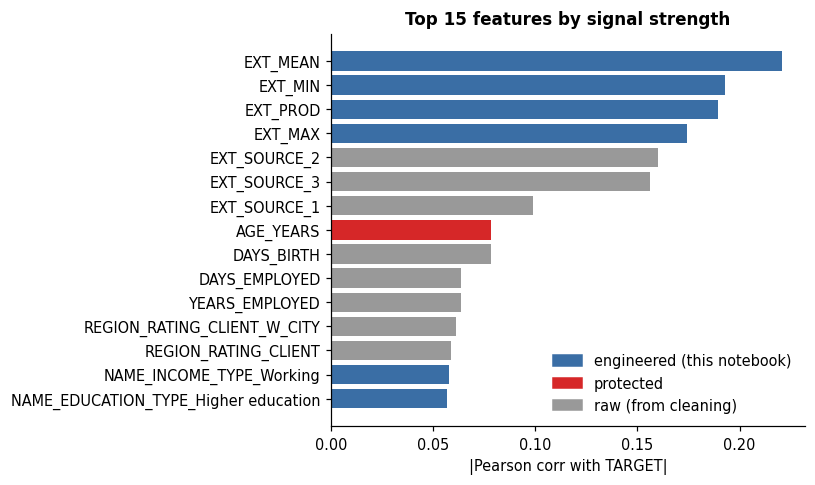


Engineered features in top-15: 6 / 15


In [14]:
# Compute |corr| with TARGET for all numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']
corrs = df[num_cols].corr()['TARGET'].drop('TARGET').abs()

eng_set = set(manifest['engineered'])
prot_set = set(manifest['protected'])

def classify(col):
    if col in eng_set:  return 'engineered'
    if col in prot_set: return 'protected'
    return 'raw'

corr_df = pd.DataFrame({
    'feature': corrs.index,
    'abs_corr': corrs.values,
    'group': [classify(c) for c in corrs.index]
}).sort_values('abs_corr', ascending=False).head(15)

fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.5))
color_map = {'engineered': NEU, 'protected': POS, 'raw': GRAY}
colors = [color_map[g] for g in corr_df['group']]
ax.barh(corr_df['feature'], corr_df['abs_corr'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('|Pearson corr with TARGET|')
ax.set_title('Top 15 features by signal strength')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=NEU,  label='engineered (this notebook)'),
    Patch(color=POS,  label='protected'),
    Patch(color=GRAY, label='raw (from cleaning)'),
], loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

print(f'\nEngineered features in top-15: '
      f'{(corr_df["group"]=="engineered").sum()} / 15')


In [15]:
# Save the features dataframe and the manifest to the working directory
# (which the notebook expects to be the project root)
OUT_CSV = 'application_train_features.csv'
OUT_JSON = 'feature_manifest.json'

df.to_csv(OUT_CSV, index=False)
with open(OUT_JSON, 'w') as f:
    json.dump(manifest, f, indent=2)

import os
size_mb = os.path.getsize(OUT_CSV) / 1e6
print(f'Saved {OUT_CSV}  ({size_mb:.1f} MB)')
print(f'Saved {OUT_JSON}')
print(f'\n✓ Feature engineering complete. Ready for modeling.')
print(f'  Dataset:  {OUT_CSV}')
print(f'  Manifest: {OUT_JSON}')
print(f'  Rows:     {len(df):,}')
print(f'  Cols:     {df.shape[1]} (8 protected + 94 engineered + 110 raw)')


Saved application_train_features.csv  (278.5 MB)
Saved feature_manifest.json

✓ Feature engineering complete. Ready for modeling.
  Dataset:  application_train_features.csv
  Manifest: feature_manifest.json
  Rows:     307,507
  Cols:     214 (8 protected + 94 engineered + 110 raw)


In [16]:
print(os.path.exists("application_train_features.csv"))

True
